In [2]:
pip install keras

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ------------- -------------------------- 1.0/3.2 MB 5.3 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 5.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import keras
from keras import layers, models
from keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the CIFAR-100 dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar100.load_data()

# Verify the shapes
print(f"Training images shape: {train_images.shape}") # (50000, 32, 32, 3)
print(f"Testing images shape: {test_images.shape}")   # (10000, 32, 32, 3)

Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)


In [2]:
# Normalize pixel values
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# One-hot encode the labels (100 classes)
train_labels = to_categorical(train_labels, 100)
test_labels = to_categorical(test_labels, 100)

In [3]:
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    
    # Classification Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Added dropout to prevent overfitting
    layers.Dense(100, activation='softmax') # 100 output units
])

C:\Users\patil\anaconda3\envs\sahilenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
# Increase epochs for better results on CIFAR-100
history = model.fit(train_images, train_labels, 
                    epochs=20, 
                    batch_size=64, 
                    validation_data=(test_images, test_labels))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 153ms/step - accuracy: 0.0640 - loss: 4.1263 - val_accuracy: 0.1577 - val_loss: 3.5731
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 163ms/step - accuracy: 0.1592 - loss: 3.5230 - val_accuracy: 0.2090 - val_loss: 3.2362
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 183ms/step - accuracy: 0.2132 - loss: 3.2203 - val_accuracy: 0.2775 - val_loss: 2.9193
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 188ms/step - accuracy: 0.2540 - loss: 3.0135 - val_accuracy: 0.3012 - val_loss: 2.8072
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 185ms/step - accuracy: 0.2829 - loss: 2.8494 - val_accuracy: 0.3345 - val_loss: 2.6545
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 163ms/step - accuracy: 0.3076 - loss: 2.7109 - val_accuracy: 0.3481 - val_loss: 2.5772
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 0.3327 - loss: 2.5950 - val_accuracy: 0.3590 - val_loss: 2.5011
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 96ms/step - accuracy: 0.3524 - l

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4070 - loss: 2.3799

Final Test Accuracy: 0.4070


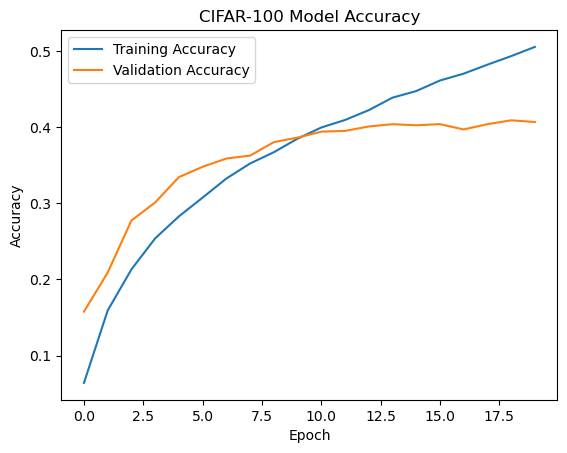

In [6]:
# Evaluate performance
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# Plot Accuracy curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CIFAR-100 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()